<a target="_blank" href="https://colab.research.google.com/github/tuankhoin/CO3057-Computer-Vision/blob/main/Week_4_Colors_Lighting_Edge.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
import os
import numpy as np
import cv2
from matplotlib import pyplot as plt

Ho Chi Minh University of Technology (HCMUT)

CO3057 - Digital Image Processing and Computer Vision

# Week 4 - Colors, Lighting and Edges

## Image Formation Model
![](https://maelfabien.github.io/assets/images/vision_2.jpg)

* Light from a source reflects off a surface
* Reflected light is captured by the camera sensor
* Pixel values depend on:

  * Illumination
  * Surface properties
  * Viewing geometry

---

## Diffuse (Lambertian) Reflectance
$$
I_D(x) = I_L R [N(x) \cdot L]
$$

Pixel intensity $I_D(x)$ depends on:

* **Light intensity** $I_L$
* **Surface reflectance** $R$ (albedo / colour)
* **Surface normal** vector $N(x)$
* **Light direction** vector $L$

The demand: Get $R$ and $N(x)$ from $I_D(x)$




---

# 1. Colour

---

## Visible Light

* Visible light spans a range of wavelengths
* Surface colour depends on how these wavelength ranges are reflected
* Described by **spectral power distribution (SPD)**

---

## Perceived Colour
![](https://upload.wikimedia.org/wikipedia/commons/thumb/0/04/Cone-fundamentals-with-srgb-spectrum.svg/500px-Cone-fundamentals-with-srgb-spectrum.svg.png)

* Human eye: **3 receptive cones**, sensitive to red, green, blue ranges (Each are 400-700 nm in range)
* Cameras: **3-sensor set** called **RGB**
* Different spectra can produce the **same perceived colour**

Sensor response formula:
$$
  Re = \int_{\lambda_{min}}^{\lambda_{max}} I_{sensitivity}(\lambda) \times \text{SPD}_{channel}(\lambda)\delta\lambda
$$

Determining a color:
1. Get $Re_{Red}$, $Re_{Green}$, $Re_{Blue}$
2. Combine these values → Final color

Try [this](https://rgbcolorpicker.com/).

---
#### Facts: Aurora Australis of the Southern Hemisphere
*Fun facts are not examinable, remember that!*
- Straya and the Southern Hemisphere also have auroras. Northern Lights is *aurora borealis* and the one in Australia is *aurora australis*.
- You can see them in Southern Victoria and Tasmania, where light pollution is little to none.
- While Northern Lights are green, Southern Lights are more red. But in most cases you cannot see the vivid colors with the naked eye because our eye cells cannot detect the color wavelength ([Source](https://www.johndcook.com/blog/2018/12/29/northern-lights/#:~:text=The%20reason%20the%20aurora%20appear,activated%20and%20color%20becomes%20visible.))! Left image is what you see, right image is what the camera sensor sees.

<img style="display:inline-block" src="https://drive.google.com/uc?export=view&id=1SZuQyhmOftTrCRDkNufga-hhoDygjXvo" width=450 height=300>
<img style="display:inline-block" src="https://drive.google.com/uc?export=view&id=1-SNW8tEz0piq9A3_FyrGm7X5HuIKk6Ru" width=450 height=300>

(Fact: I took this image in 2/2022 at Koo Wee Rup, 60km from Melbourne CBD)

---

## Common colour spaces:

| Color Model | Description                          | Channels Represent |
|-------------|--------------------------------------|--------------------|
| **RGB**     | Device-based, common in imaging      | Red, Green, Blue   |
| **HSV**     | Intuitive, human-friendly            | Hue, Saturation, Value |
| **HSL**     | Intuitive, human-friendly            | Hue, Saturation, Lightness |
| **CIE XYZ** | Perceptual basis                     | X (red-green), Y (luminance), Z (blue) |
| **LAB**     | Approximately perceptually uniform   | L* (lightness), a* (green–red), b* (blue–yellow) |


### Converting from one to another
* Colour conversion is typically linear:
$
  \begin{bmatrix} X \\ Y \\ Z \end{bmatrix}
  =
  M
  \begin{bmatrix} R \\ G \\ B \end{bmatrix}
$
* Matrix depends on colour space and white point
* Implemented in OpenCV, scikit-image, etc.

<img style="float: ;" src="https://b2633864.smushcdn.com/2633864/wp-content/uploads/2021/04/opencv_color_spaces_lab_sphere.png?lossy=1&strip=1&webp=1" width=320 height=300>

<div>
<img style="display: inline-block" src="https://wiki.loliot.net/img/lang/python/libraries/opencv/opencv-color.png" width=500 height=500>
</div>

- [`cv2.cvtColor( )`](https://docs.opencv.org/4.6.0/d8/d01/group__imgproc__color__conversions.html)

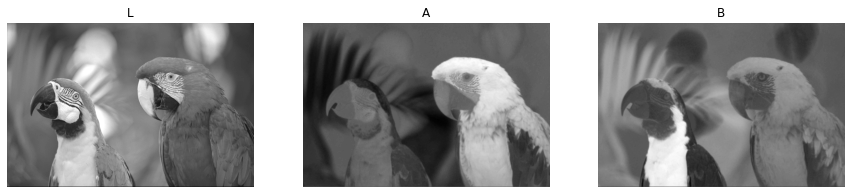

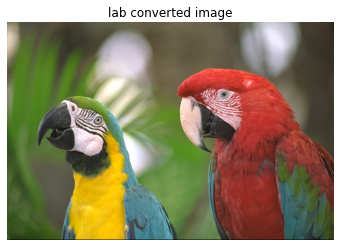

In [ ]:
# @title
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)

fig,axs = plt.subplots(1,4)
fig.set_figwidth(20)
fig.set_figheight(20)

plt.subplot(1,4,1)
plt.imshow(img_lab[:,:,0],cmap='gray')
plt.title('L')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(img_lab[:,:,1],cmap='gray')
plt.title('A')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(img_lab[:,:,2],cmap='gray')
plt.title('B')
plt.axis('off')

img_cvt = cv2.cvtColor(img_lab, cv2.COLOR_Lab2BGR)

#rearrange the channel for showing image
img2 = np.zeros(img_cvt.shape,np.uint8)
img2[:,:,0] = img_cvt[:,:,2] #red
img2[:,:,1] = img_cvt[:,:,1] #green
img2[:,:,2] = img_cvt[:,:,0] #blue

plt.subplot(1,4,4)
plt.imshow(img2)
plt.title('lab converted image')
plt.axis('off')

plt.show()


---

# 2. Shading and Surfaces
Goal
* Recover **surface normals** and **light direction**
* Enables inference of **3D shape**
---

## The mathematical way
$$
I_D(x) \propto N(x) \cdot L = \cos \theta_x
$$

* Can get **angle**, but not unique normal
* Produces a **family of possible normals**

Additional assumptions help:
* Normals at object boundaries are known
* Neighboring normals are similar
* Surfaces are smooth

---
## The Shady Way (using shading)

* Recover 3D shape **using only shading**
* Requires strong **assumptions**, no one-size-fits-all.
* **Sensitive** to noise and lighting

How could human do it?

---

## Human Perception Priors

![](https://github.com/tuankhoin/CO3057-Computer-Vision/blob/main/assets/w4hypno.JPG?raw=true)

Humans succeed using powerful **prior** knowledge (system of assumptions that are correct 80% of the time).

Some examples (non-examinable):

| Prior Name | Description of Effect |
| :--- | :--- |
| **Light-from-Above** | The assumption that light hits objects from overhead, causing top-shaded areas to be perceived as protruding (convex) and bottom-shaded areas as receding (concave). |
| **Convexity** | A strong bias to perceive objects—especially familiar ones like faces—as outward-protruding surfaces rather than hollow cavities. |
| **Shadow/Context** | The brain automatically adjusts the perceived brightness of a surface by accounting for the presence of cast shadows. |
| **Perspective** | The interpretation of converging lines as depth, leading the brain to perceive objects further along those lines as being physically larger. |
| **Rigid Motion** | The assumption that a collection of moving points maintains a fixed 3D structure rather than changing shape independently. |
| **Cardinal Bias** | An inherent bias that prioritizes the processing of vertical and horizontal orientations over diagonal (oblique) ones. |
| **Smoothness** | The expectation that objects move along the shortest, most continuous path rather than making abrupt, disjointed jumps. |

![](https://github.com/tuankhoin/CO3057-Computer-Vision/blob/main/assets/w4prior.JPG?raw=true)

Have a look at some examples [here](https://www.rd.com/article/optical-illusions/).


---

## 3. Separating Reflectance vs Illumination

Observed luminance: $
L = R \times I
$

![](https://i.ytimg.com/vi/YGEBATgrBPM/hqdefault.jpg)

---

## Reflectance from Frequency

Assumption:

* Illumination varies **smoothly** (low frequency)
* Reflectance causes **sharp changes** (high frequency)

⇒ Remove low-frequency components using Fourier

$$
L = R \times I \\
⇒ \ln(L) = \ln(R) + \ln(I)\\
$$$$
⇒ R \approx e^{FT^{-1}(g \cdot FT(\ln L))} \tag{g: high-pass filter}
$$

---

## Hard Cases

* **Cast shadows**: illumination not constant
* **Specularity**: view-dependent reflection
* **Anisotropy**: direction-dependent reflection
* **Transparency / translucency**: light passes through surfaces

These make inverse inference extremely difficult. In reality, most surfaces are not matte (Lambertian).


---

# 4. Edges

---

![](https://github.com/tuankhoin/CO3057-Computer-Vision/blob/main/assets/w4edge.png?raw=true)

Edges arise from **discontinuities** in image formation:

* **Surface normal discontinuity**:
  Changes in surface orientation (corners, folds)
* **Depth discontinuity**:
  Different surfaces at different depths
* **Surface colour (reflectance) discontinuity**:
  Patterns, textures, markings
* **Illumination discontinuity**:
  Shadows, lighting changes
  → Most problematic: not tied to surface or material

---

## Characteristics
![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSYMITm58_jwXjw0r-ybYPeuUOeu3Gs0zvaag&s)

* Edges correspond to **rapid intensity changes**
* Consider a 1D slice of the image:
  * Flat regions → constant intensity
  * Sharp transitions → edges
* Edges appear as **extrema in the derivative**

---

## Gradient

For an image $f(x,y)$, the gradient is a **vector**:

$$
\nabla f = \frac{\partial f}{\partial x} \overrightarrow{\mathbf{x_i}} + \frac{\partial f}{\partial y}\overrightarrow{\mathbf{y_j}}
$$

* **Direction** (edge orientation):
  $$
  \theta = \tan^{-1}\left(\frac{\partial f/\partial y}{\partial f/\partial x}\right)
  $$

* **Magnitude** (edge strength):
  $$
  |\nabla f| =
  \sqrt{\left(\frac{\partial f}{\partial x}\right)^2 +
  \left(\frac{\partial f}{\partial y}\right)^2}
  $$

Characteristics:
* $\frac{\partial f}{\partial x}$ responds strongly to **vertical edges**
* $\frac{\partial f}{\partial y}$ responds strongly to **horizontal edges**
* Together, they describe local edge structure

---

## Issue: Noise

![](https://velog.velcdn.com/images/m2nja201/post/f24a5887-c003-4997-ae7d-eaf1eb914322/image.png)

* Images are noisy signals
* Differentiation **amplifies noise**
* Raw derivatives produce many **false edge responses**
* True edges become hard to identify

---

## Solution: Smooth First

* Apply Gaussian smoothing before differentiation
* Reduces noise while preserving large-scale edges
* Edge locations become clearer after smoothing

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FbZYqvN%2Fbtrx5AnwP5M%2FAAAAAAAAAAAAAAAAAAAAAEwHox21rjx2SdvCl_dISzuuDUxAFhcqfAjJyAlqUTkQ%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1772290799%26allow_ip%3D%26allow_referer%3D%26signature%3DfB9ooCVctOGuDtPI2ZgP0URg%252Fio%253D)

Going more efficient: use convolution properties

$$
\frac{d}{dx}(f * g) = f * \frac{d}{dx} g
$$

* Smooth and differentiate **in one step**
* Leads to **derivative-of-Gaussian filters**

![](https://i.ytimg.com/vi/_jzQbAZQqoA/sddefault.jpg)

---

## Edge Filter: Sobel

* Sobel filters approximate:
  * Gaussian smoothing
  * Followed by differentiation
* Simple, efficient edge detectors
* Compute gradients in $x$ and $y$


---

# 5. Canny Edge Detection

---

## Canny: Gradient Computation

* Smooth image with Gaussian
* Compute gradients using derivative filters
* Only two derivatives needed ($x$ and $y$) to calculate any other directions  (Trigonometry: remember your Pythagoras Theorem!)

Directional derivative:
$$
\frac{d}{d\theta}
= \cos(\theta)\frac{d}{dx} + \sin(\theta)\frac{d}{dy}
$$


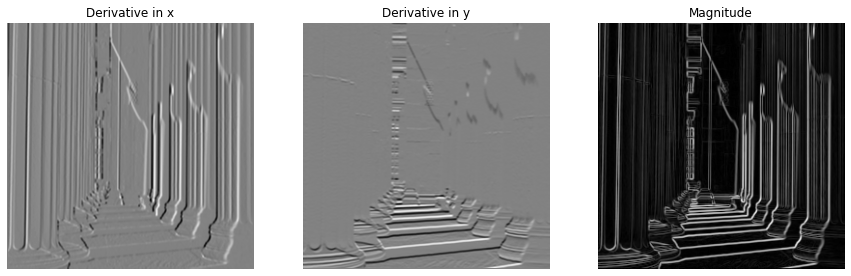

In [ ]:
# @title
# X-Direction Kernel (Vertical)
sobel_kernel_x = np.array([[1,0,-1], [2,0,-2], [1,0,-1]])
# Y-Direction Kernel (Horizontal)
sobel_kernel_y = np.array([[1,2,1], [0,0,0], [-1,-2,-1]])

# Use Sobel filter to approximate the derivative of gaussian (for both x and y)
dx = cv2.filter2D(org_img,-1,sobel_kernel_x)
dy = cv2.filter2D(org_img,-1,sobel_kernel_y)

magnitude = np.hypot(dx, dy)   # equivalent to sqrt(x1**2 + x2**2), element-wise
angle = np.arctan2(dy, dx)     # Element-wise arc tangent of dy/dx

fig,axs = plt.subplots(1,3)
fig.set_figwidth(15)
fig.set_figheight(15)

plt.subplot(1,3,1)
plt.imshow(dx,cmap='gray')
plt.title('Derivative in x')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(dy,cmap='gray')
plt.title('Derivative in y')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(magnitude,cmap='gray')
plt.title('Magnitude')
plt.axis('off')

plt.show()



---

## Problem: Multiple Edge Responses

![](https://blog.roboflow.com/content/images/2026/01/2-6.png)

* Thick edges produce many nearby gradient responses
* Humans see **one edge**
* Computers see **many responses**
* Need to keep only the most representative pixel

---

## Non-Maximum Suppression

![](https://github.com/tuankhoin/CO3057-Computer-Vision/blob/main/assets/w4nms.png?raw=true)

* For each pixel:
  * Compare magnitude with neighbours along gradient direction
  * Keep pixel only if it is a **local maximum**
* Produces thin, one-pixel-wide edges

---

## Hysteresis Thresholding
![](https://i.ytimg.com/vi/81iug5A3-jE/maxresdefault.jpg)

Problem: No single threshold works reliably. Low-contrast will be missed!
* Solution: Use two thresholds $T_1 > T_2$:
  * Strong edges: magnitude $> T_1$
  * Weak edges: $T_2 < $ magnitude $< T_1$
* Keep weak edges **only if connected to strong edges** (8-direction neighbor)
* Removes noise while preserving true edges



## Overall

The process of Canny Edge Detection algorithm can be broken down to multi-stage:

1. Apply Gaussian filter to smooth the image in order to remove the noise
2. Find edge magnitute and direction (Gradient Calculation)
3. Apply Non-Maximum Suppression to thin the edges
4. Apply Hysteresis Thresholding to find "really edges" and further reduce the noise.

Time:  0.0007074170000009872


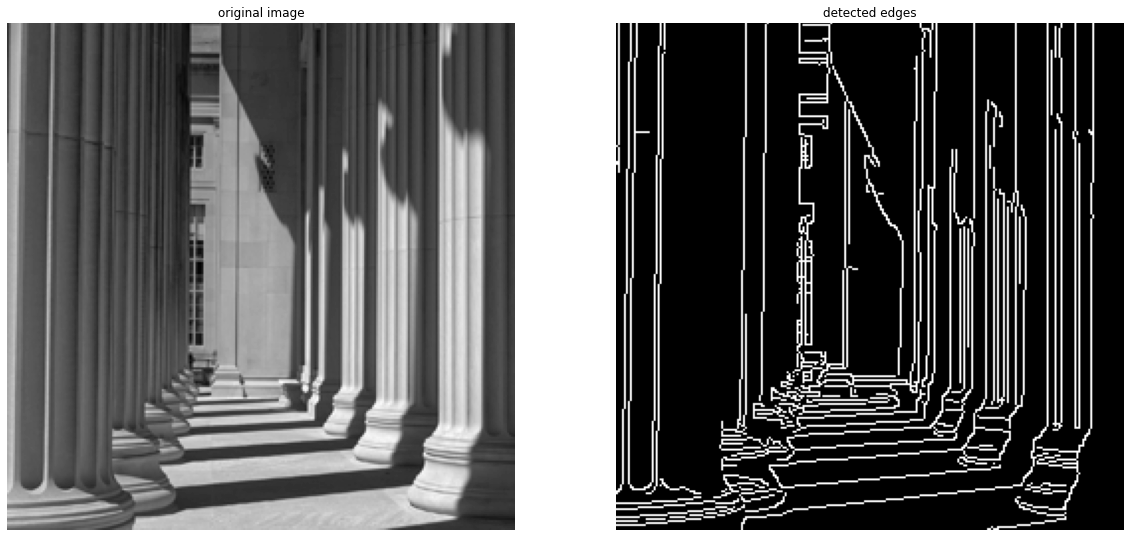

In [ ]:
org_img = cv2.imread(path+"cannyimg.png",cv2.IMREAD_GRAYSCALE )

start = timeit.default_timer()

edge_img = cv2.Canny(org_img,50,200,3,L2gradient=True) #two thresholds in Hysteresis Thresholding and Aperture size of the Sobel

stop = timeit.default_timer()
print('Time: ', stop - start)

fig,axs = plt.subplots(1,2)
fig.set_figwidth(10)
fig.set_figheight(10)

plt.subplot(1,2,1)
plt.imshow(org_img ,cmap='gray')
plt.title('original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edge_img ,cmap='gray')
plt.title('detected edges')
plt.axis('off')

plt.show()

---

# 6. Edges for Image Recognition

---

## Why Edges Matter

* Edges capture **structural information**
* Humans rely heavily on edges for perception
* Neural networks learn edge-like filters in early layers
* Efficient representation (compression): Only encode where the signal changes

---

## Invariance and Tolerance

* **Invariant to $X$**: representation unchanged by $X$
* **Tolerant to $X$**: representation changes little with $X$

Goal: features that ignore irrelevant variation

---

## Invariant to Light Intensity?

* Derivatives are invariant to intensity shifts:
  $
  I_{\text{new}} = I + b
  $
* Tolerant to contrast scaling:
  $
  I_{\text{new}} = aI
  $
  (depending on thresholds)

---

## Invariant to Light Direction?

* Edge locations depend on surface geometry
* Often stable under lighting direction changes
* Especially true for strong geometric edges

---

## Invariant to Translation?

* Translation shifts edge positions
* Local gradient structure remains the same
* Edge detectors are translation invariant

---

## Invariant to Rotation?

* Edge **existence** preserved
* Edge **orientation** changes
* Rotation invariance requires normalization or matching across orientations

---

## Invariant to Scale?
![](https://github.com/tuankhoin/CO3057-Computer-Vision/blob/main/assets/w4scale.png?raw=true)
* Edges are **not scale invariant**
* Fine edges may disappear at coarser scales
* Multiscale approaches are required

---

## Invariant to 3D Pose?

* Edges change under 3D rotation
* Exact invariance impossible
* Robust matching uses multiple viewpoints or learned features

---

## Image Recognition

To recognize objects across variation:

* Learn **invariant features**
* Or learn multiple feature sets for different conditions
* Most systems combine both strategies


---
# 7. Exercises

---

Assume that all surfaces in the image below are Lambertian (diffuse reflectance) surfaces, and the scene is lit by a single light source.

### 1. What are the scene/object parameters that determine the R,G,B value of each pixel in this scene?


### 2. At the region indicated by the circle and arrow, which of the parameters you listed above are changing and which are constant?

<img style="float: ;" src="https://raw.githubusercontent.com/saraao/COMP90086_image/main/img1.png" width=300 height=200>

<img style="float: ;" src="https://raw.githubusercontent.com/saraao/COMP90086_image/main/img2.png" width=300 height=200>


<img style="float: ;" src="https://raw.githubusercontent.com/saraao/COMP90086_image/main/img3.png" width=300 height=200>


Answer Q1:
- Colour of light source
- Reflectance of surface
- Angle between surface
- Light source.

Answer Q2:
1. Light source is changing, other parameters are constant.
2. Reflectance is changing, other parameters are constant.
3. Reflectance and angle are changing, light source is constant.